<a href="https://colab.research.google.com/github/mayurimamdi/FraudDetectionEDA/blob/main/FraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path= "/content/drive/MyDrive/FraudDetection/bank_transactions_data_2.csv"

In [ ]:
df=pd.read_csv(file_path)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [ ]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [ ]:
df.shape


(2512, 16)

In [ ]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
TransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['TransactionAmount'].describe()

,TransactionAmount
count,2512.000000
mean,297.593778
std,291.946243
min,0.260000
25%,81.885000
50%,211.140000
75%,414.527500
max,1919.110000


In [ ]:
df['LoginAttempts'].value_counts()

,count
LoginAttempts,
1,2390
5,32
4,32
3,31
2,27


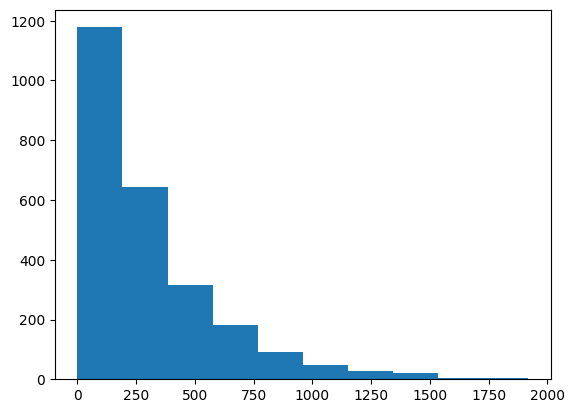

In [ ]:
plt.hist(df['TransactionAmount'])
plt.show()

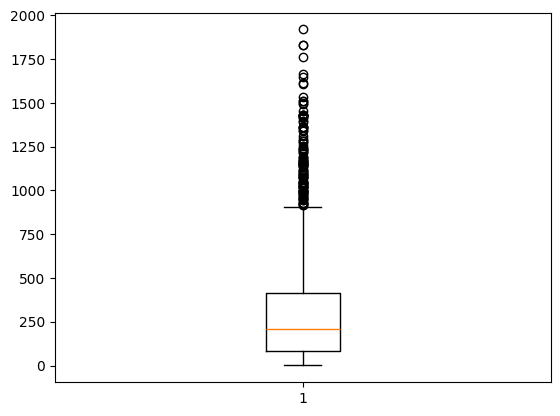

In [ ]:
plt.boxplot(df['TransactionAmount'])
plt.show()

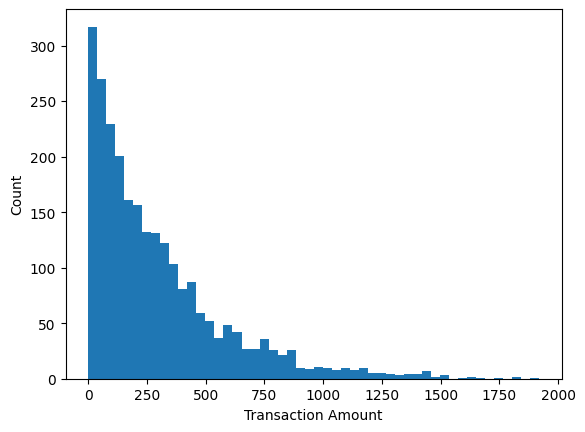

In [ ]:
plt.hist(df['TransactionAmount'], bins=50)
plt.xlabel("Transaction Amount")
plt.ylabel("Count")
plt.show()

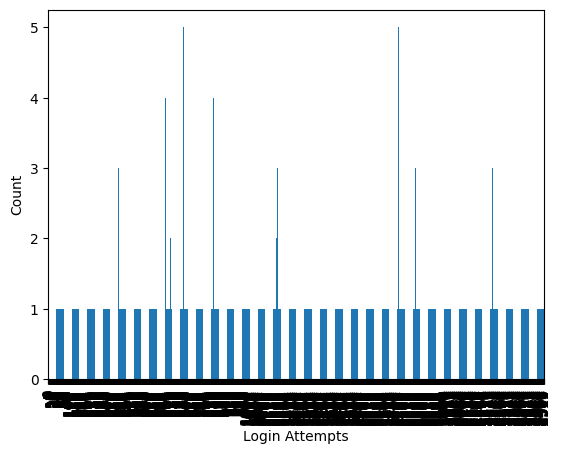

In [ ]:
df['LoginAttempts'].plot(kind='bar')
plt.xlabel("Login Attempts")
plt.ylabel("Count")
plt.show()

In [ ]:
df['CustomerAge'].describe()

,CustomerAge
count,2512.000000
mean,44.673965
std,17.792198
min,18.000000
25%,27.000000
50%,45.000000
75%,59.000000
max,80.000000


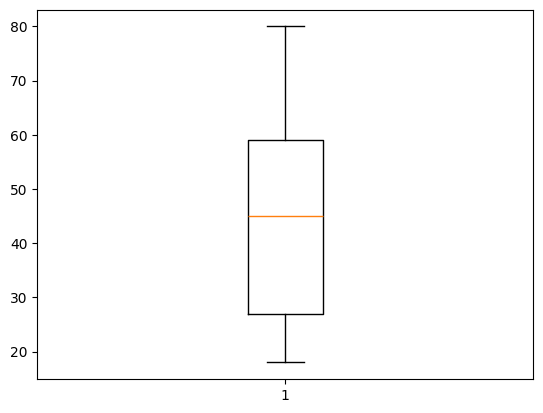

In [ ]:
plt.boxplot(df['CustomerAge'])
plt.show()

In [ ]:
df['TransactionDuration'].describe()

,TransactionDuration
count,2512.000000
mean,119.643312
std,69.963757
min,10.000000
25%,63.000000
50%,112.500000
75%,161.000000
max,300.000000


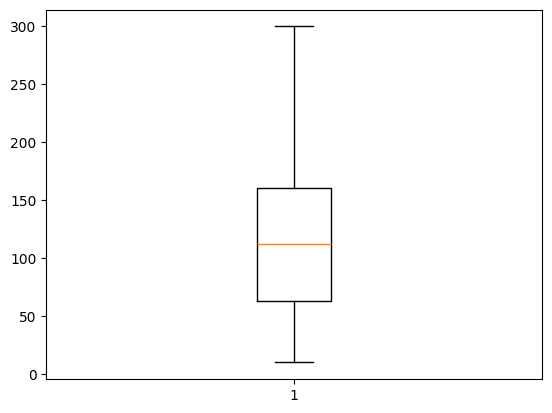

In [ ]:
plt.boxplot(df['TransactionDuration'])
plt.show()

In [ ]:
df['TransactionType'].value_counts()

,count
TransactionType,
Debit,1944
Credit,568


In [ ]:
df['Channel'].value_counts()

,count
Channel,
Branch,868
ATM,833
Online,811


In [ ]:
df[['TransactionAmount','LoginAttempts','AccountBalance']].corr()


,TransactionAmount,LoginAttempts,AccountBalance
TransactionAmount,1.000000,-0.008445,-0.025165
LoginAttempts,-0.008445,1.000000,0.014999
AccountBalance,-0.025165,0.014999,1.000000


In [ ]:
df['IP Address'].value_counts().head()


,count
IP Address,
200.136.146.93,13
49.31.186.82,11
173.135.78.201,10
9.230.41.239,10
166.79.195.157,10
